In [1]:
from FFNN import FFNN
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state

In [2]:
t0 = time.time()
train_samples = 50000

In [3]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [4]:
random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

In [5]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=train_samples, test_size=0.2
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Configure MLPClassifier
clf = MLPClassifier(
    hidden_layer_sizes=(20, ),  # One hidden layer with 100 neurons
    max_iter=10,  # Reduced for faster convergence
)

clf.fit(X_train, y_train)
score = clf.score(X_test, y_test)

print("Test score with MLPClassifier: %.4f" % score)

Test score with MLPClassifier: 0.9488


c:\Users\Amalia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


In [8]:
model = FFNN(
    layers=[X_train.shape[1], 20, 20, 10],
    activation_functions=["relu", "relu", "sigmoid"],
    loss_function="categorical_cross_entropy",
    random_state=42, learning_rate=0.1, epoch=10, verbose=1, 
    batch_size=1
)

model.weight_initializer(weight_initializer="normal", mean=0.5, variance=0.1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = np.mean(y_pred == y_test)
print("Test score with FFNN: %.4f" % score)

Epoch 1, Training Loss: 1.9468233983824453e-05
Epoch 2, Training Loss: 1.6574438224600985e-06
Epoch 3, Training Loss: 9.352778740565647e-07
Epoch 4, Training Loss: 6.487116280092984e-07
Epoch 5, Training Loss: 4.950107598415018e-07
Epoch 6, Training Loss: 3.992572367616585e-07
Epoch 7, Training Loss: 3.339972062319735e-07
Epoch 8, Training Loss: 2.8670432188786893e-07
Epoch 9, Training Loss: 2.509121758224676e-07
Epoch 10, Training Loss: 2.2289502694558944e-07
Training completed.
Test score with FFNN: 0.0991


In [11]:
# model = FFNN(layers=[2, 16, 1], activation_functions=["relu", "linear"], loss_function="mse", batch_size=None, learning_rate=0.1, epoch=1000, verbose=1, random_state=10)
# model.weight_initializer(weight_initializer="normal", mean=0, variance=1, seed=10)
# model.fit(X, y)

In [9]:
# Visualize weights of the first hidden layer
plt.figure(figsize=(10, 5))
weights = clf.coefs_[0]  # Weights of the first hidden layer
scale = np.abs(weights).max()
for i in range(10):
    l1_plot = plt.subplot(2, 5, i + 1)
    l1_plot.imshow(
        weights[:, i].reshape(28, 28),
        interpolation="nearest",
        cmap=plt.cm.RdBu,
        vmin=-scale,
        vmax=scale,
    )
    l1_plot.set_xticks(())
    l1_plot.set_yticks(())
    l1_plot.set_xlabel("Neuron %i" % i)

plt.suptitle("First Hidden Layer Weights")
run_time = time.time() - t0
print("Example run in %.3f s" % run_time)
plt.show()

NameError: name 'clf' is not defined

<Figure size 1000x500 with 0 Axes>

In [13]:
run_time = time.time() - t0
print("Example run in %.3f s" % run_time)
plt.show()

Example run in 12149.245 s


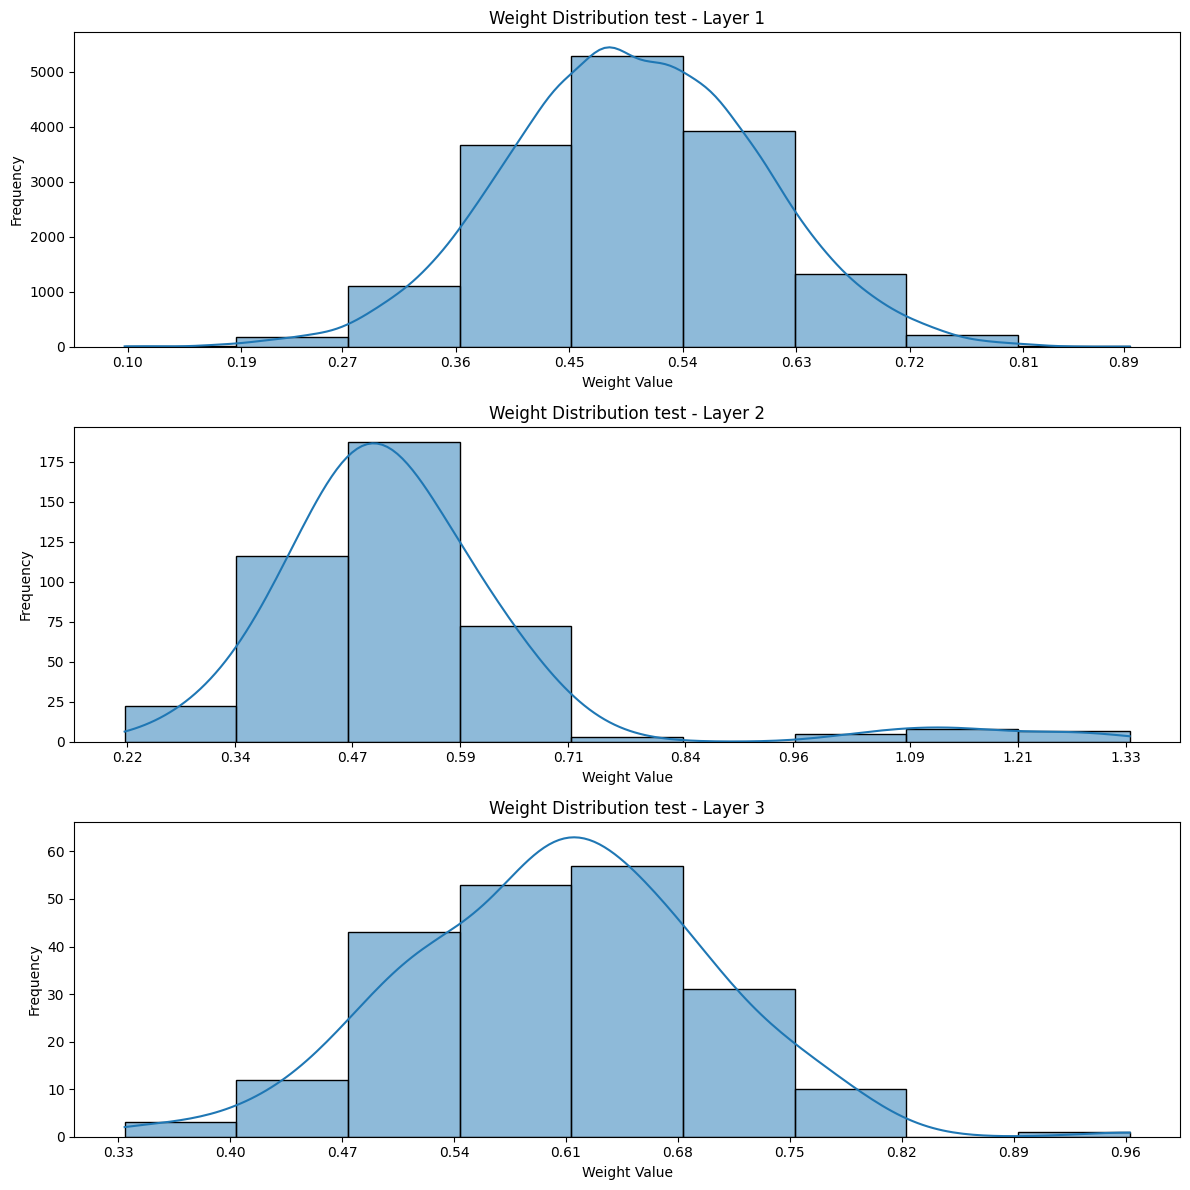

In [11]:
model.visualize_weight_distributions([0, 1, 2], name="test")

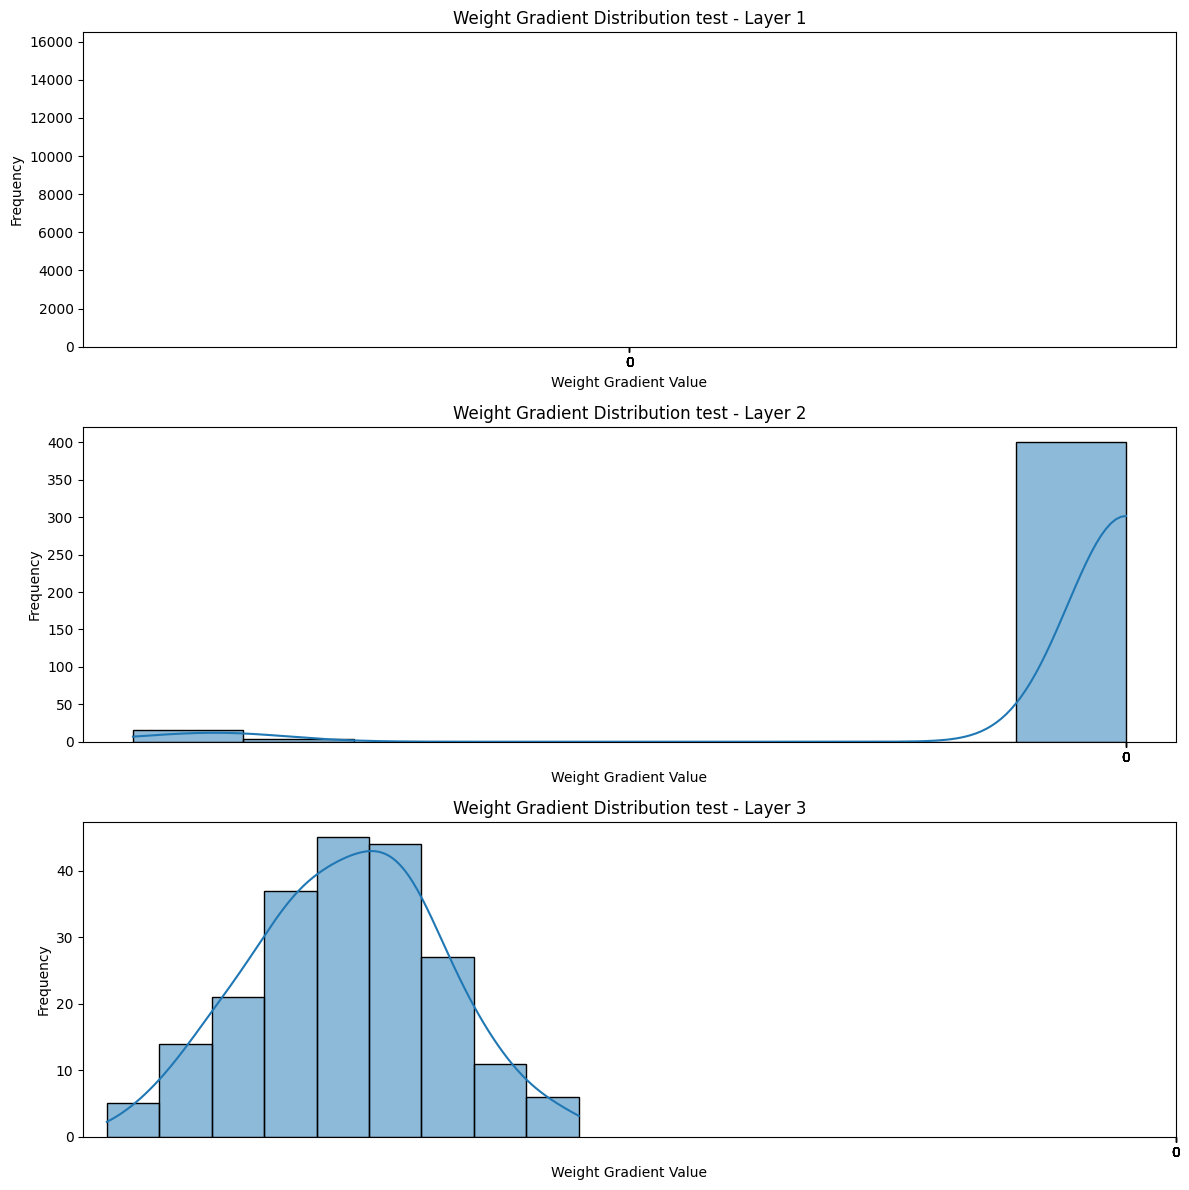

In [12]:
model.visualize_weight_gradient_distributions([0, 1, 2], name="test")